<a href="https://colab.research.google.com/github/tauqeer-jetcom/ipl-match-winner-prediction/blob/main/IPL_Match_Winner_Prediction_Based_on_Historical_Data_Using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

data = pd.read_csv("ipl_matches_data.csv")
data

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,result,player_of_match
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,win,46.0
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,win,15.0
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,win,36.0
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,win,57.0
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,win,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207,1529282,2026,6,Delhi,2026-04-27,Indian Premier League,39.0,male,T20,T20,...,"Arun Jaitley Stadium, Delhi",1,252,1,field,1,NaN,9.0,win,4664.0
1208,1529283,2026,6,New Chandigarh,2026-04-28,Indian Premier League,40.0,male,T20,T20,...,Maharaja Yadavindra Singh International Cricke...,134,494,134,field,134,NaN,6.0,win,11389.0
1209,1529284,2026,6,Mumbai,2026-04-29,Indian Premier League,41.0,male,T20,T20,...,"Wankhede Stadium, Mumbai",3,3,2,bat,2,NaN,6.0,win,1740.0
1210,1529285,2026,6,Ahmedabad,2026-04-30,Indian Premier League,42.0,male,T20,T20,...,"Narendra Modi Stadium, Ahmedabad",615,1,615,field,615,NaN,4.0,win,4098.0


In [ ]:
data.size

data.columns

data.isnull().sum()

,0
match_id,0
season_id,0
balls_per_over,0
city,51
match_date,0
event_name,0
match_number,70
gender,0
match_type,0
format,0


In [ ]:
data = data.drop('match_id', axis=1)
data.dropna(subset=['city'], inplace=True)
data['match_number'].fillna(data['match_number'].mean(), inplace=True)
data['win_by_runs'].fillna(data['win_by_runs'].mean(), inplace=True)
data['win_by_wickets'].fillna(data['win_by_wickets'].mean(), inplace=True)
data['player_of_match'].fillna(data['player_of_match'].mean(), inplace=True)
print(data.isnull().sum())

season_id          0
balls_per_over     0
city               0
match_date         0
event_name         0
match_number       0
gender             0
match_type         0
format             0
overs              0
season             0
team_type          0
venue              0
toss_winner        0
team1              0
team2              0
toss_decision      0
match_winner       0
win_by_runs        0
win_by_wickets     0
result             0
player_of_match    0
dtype: int64


/tmp/ipykernel_2106/4031120177.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['match_number'].fillna(data['match_number'].mean(), inplace=True)
/tmp/ipykernel_2106/4031120177.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [ ]:
data.isnull().sum()

,0
season_id,0
balls_per_over,0
city,0
match_date,0
event_name,0
match_number,0
gender,0
match_type,0
format,0
overs,0


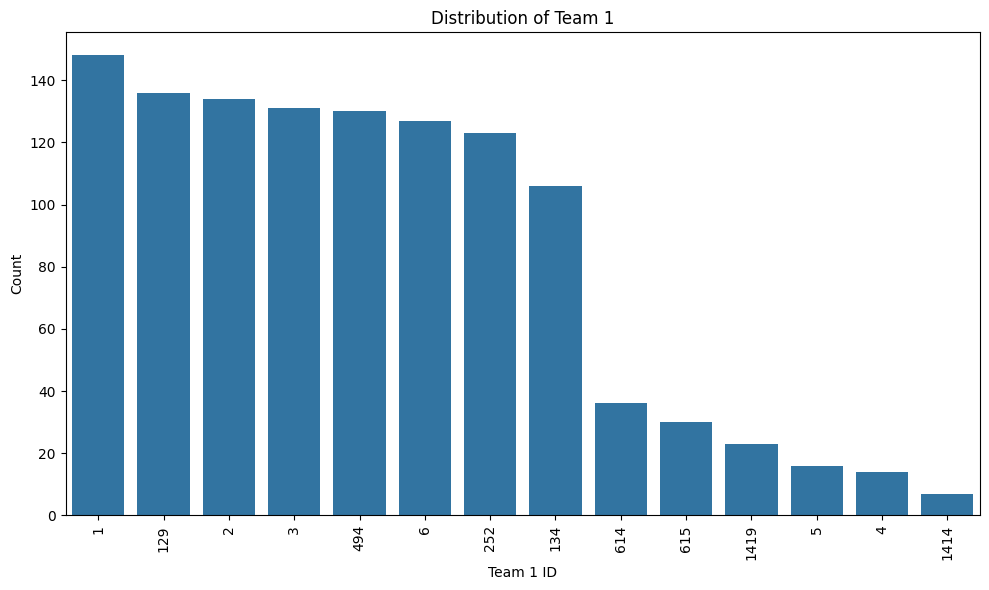

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='team1', order=data['team1'].value_counts().index)
plt.title('Distribution of Team 1')
plt.xlabel('Team 1 ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

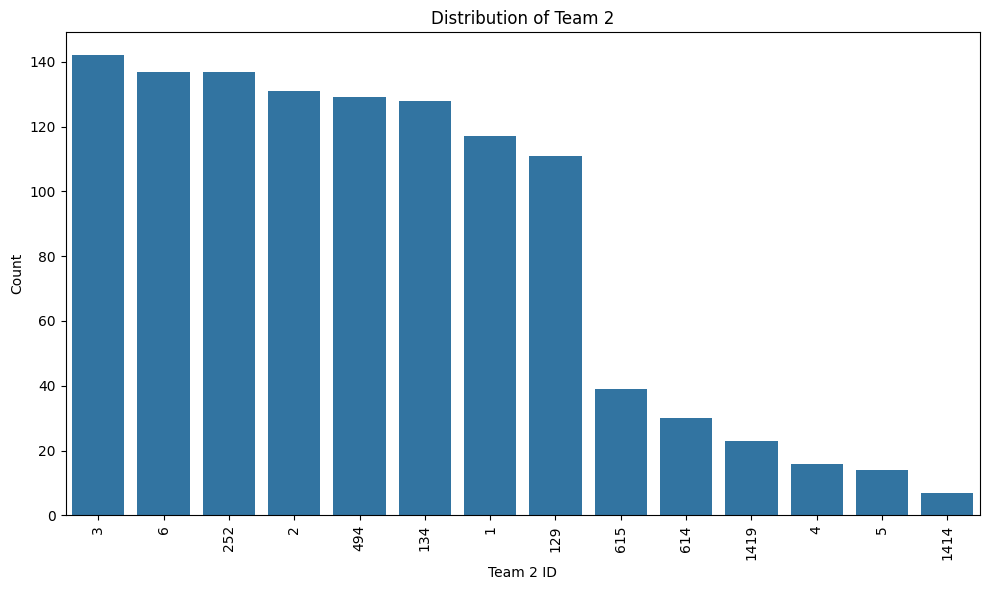

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='team2', order=data['team2'].value_counts().index)
plt.title('Distribution of Team 2')
plt.xlabel('Team 2 ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

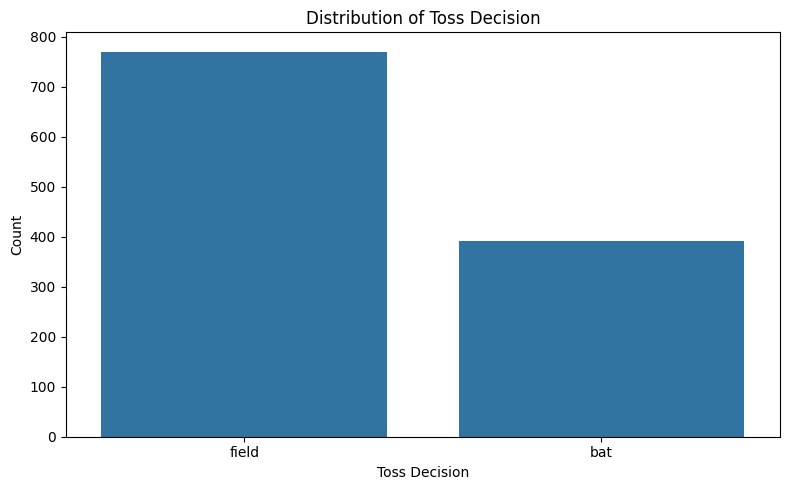

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='toss_decision')
plt.title('Distribution of Toss Decision')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

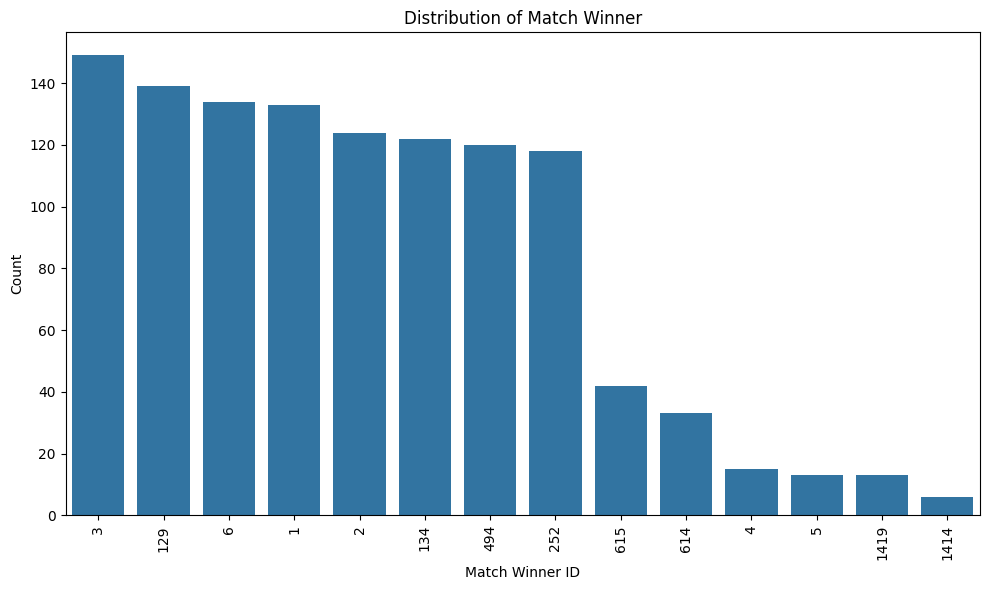

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='match_winner', order=data['match_winner'].value_counts().index)
plt.title('Distribution of Match Winner')
plt.xlabel('Match Winner ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

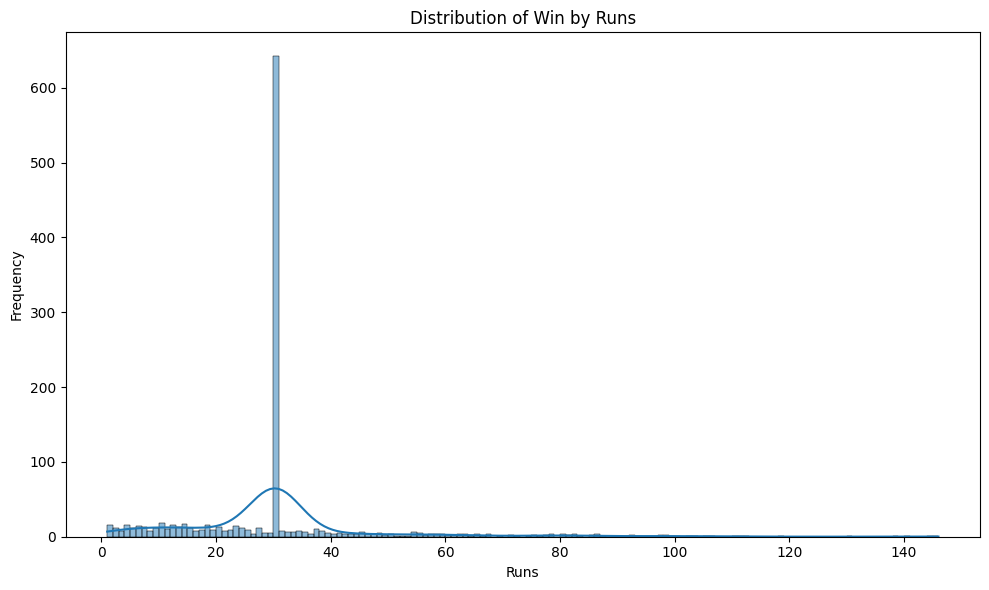

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='win_by_runs', kde=True)
plt.title('Distribution of Win by Runs')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

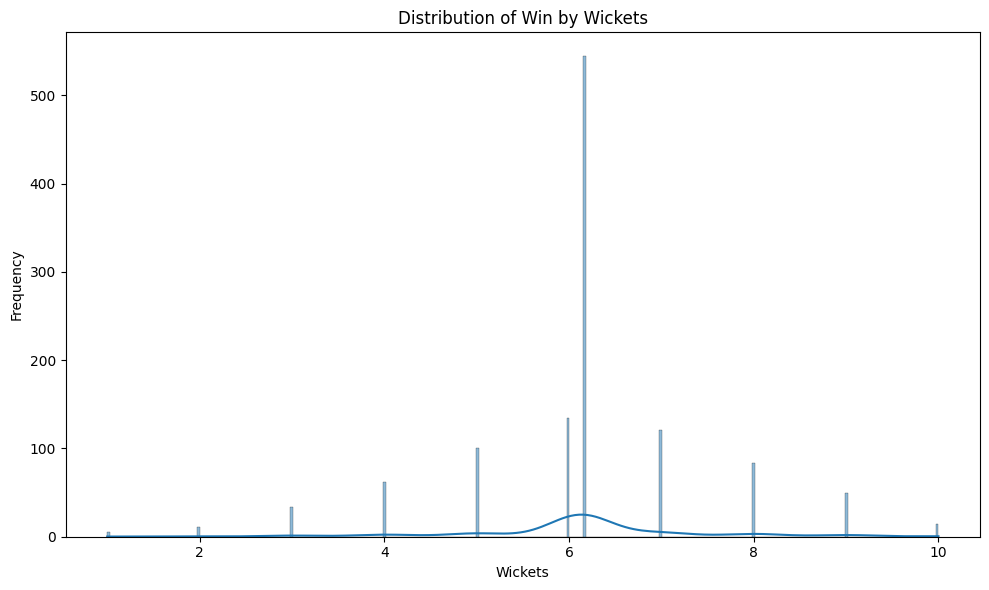

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='win_by_wickets', kde=True)
plt.title('Distribution of Win by Wickets')
plt.xlabel('Wickets')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

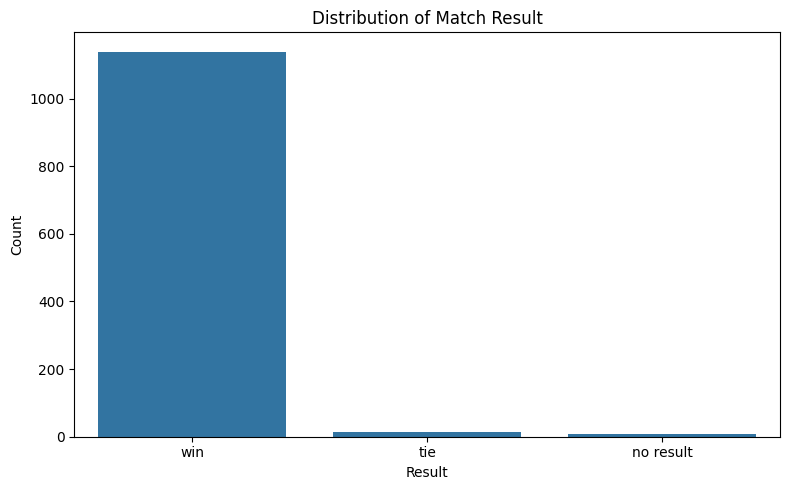

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='result')
plt.title('Distribution of Match Result')
plt.xlabel('Result')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

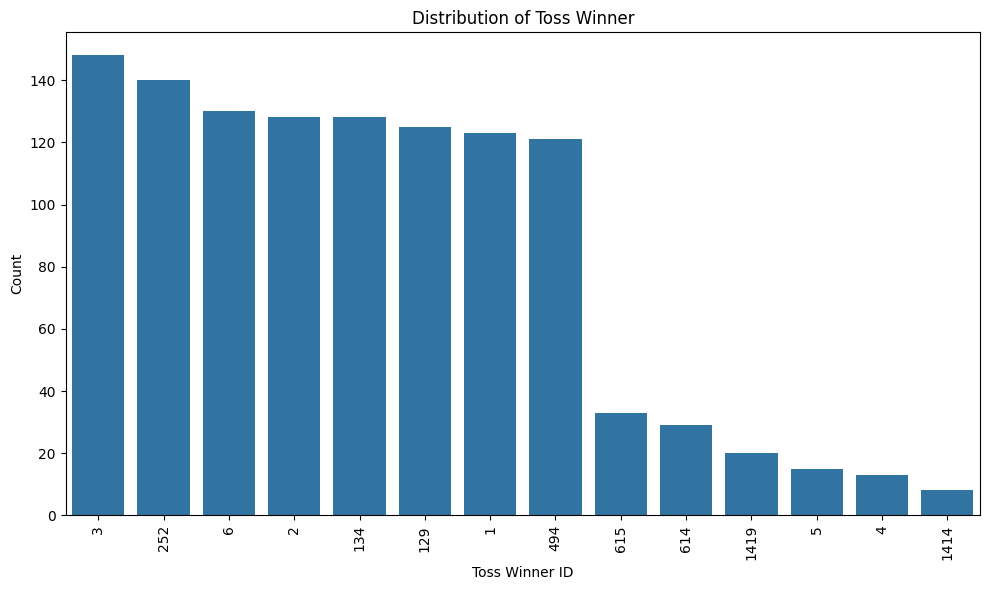

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='toss_winner', order=data['toss_winner'].value_counts().index)
plt.title('Distribution of Toss Winner')
plt.xlabel('Toss Winner ID')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

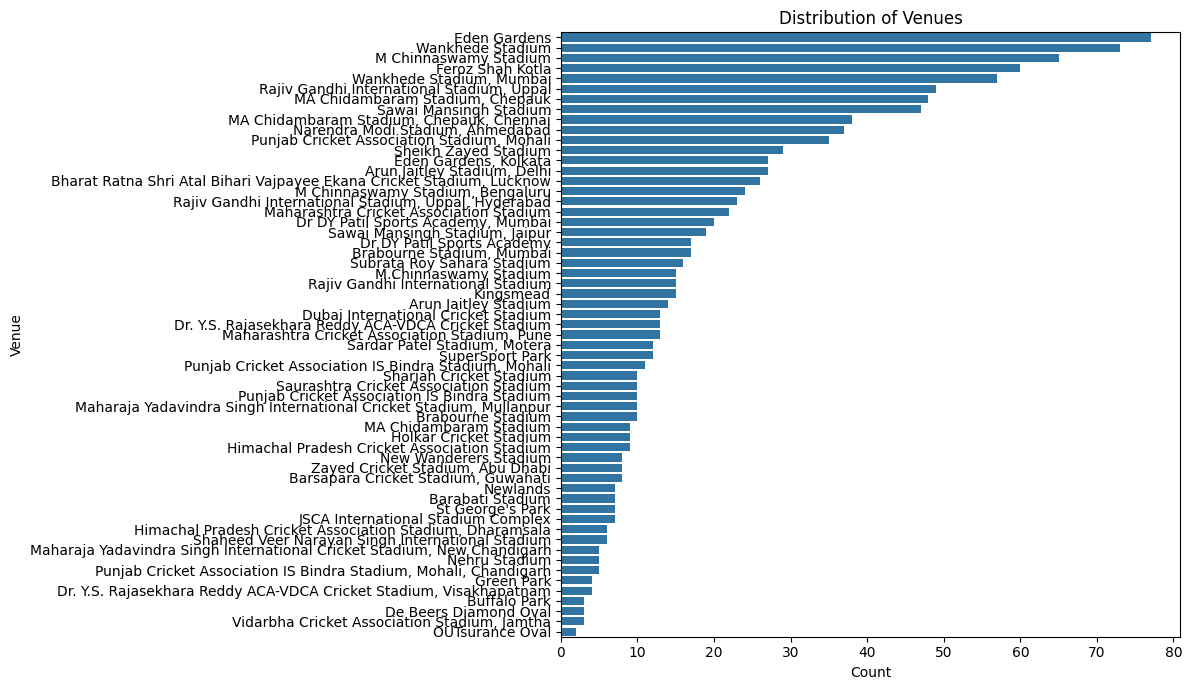

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=data, y='venue', order=data['venue'].value_counts().index)
plt.title('Distribution of Venues')
plt.xlabel('Count')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

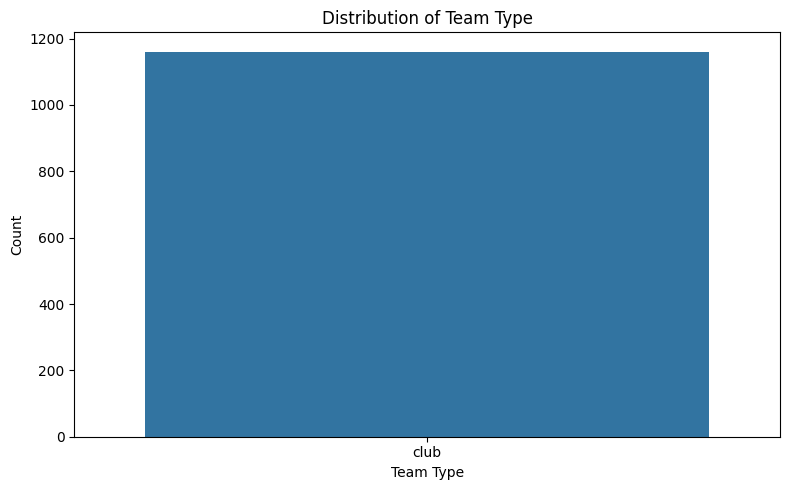

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='team_type')
plt.title('Distribution of Team Type')
plt.xlabel('Team Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier   # Changed to CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Identify categorical columns (object type) to encode
categorical_cols = data.select_dtypes(include='object').columns

# Apply Label Encoding to all identified categorical columns in the 'data' DataFrame
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Now that all categorical columns are encoded, define x and y
x = data.drop(['match_winner'], axis=1)
y = data['match_winner']

# Perform train-test split on the encoded data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Changed to CatBoostClassifier, and removed loss_function='RMSE' as it's for regression
model = CatBoostClassifier(iterations=1000, learning_rate=0.05, depth=6, verbose=0)
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7124463519313304
Precision: 0.6970407081835343
Recall: 0.7124463519313304
F1 Score: 0.6921281487173938


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Feature Importance Analysis for CatBoostClassifier

To understand which features are most impactful in the `CatBoostClassifier`'s predictions, let's visualize the feature importances.

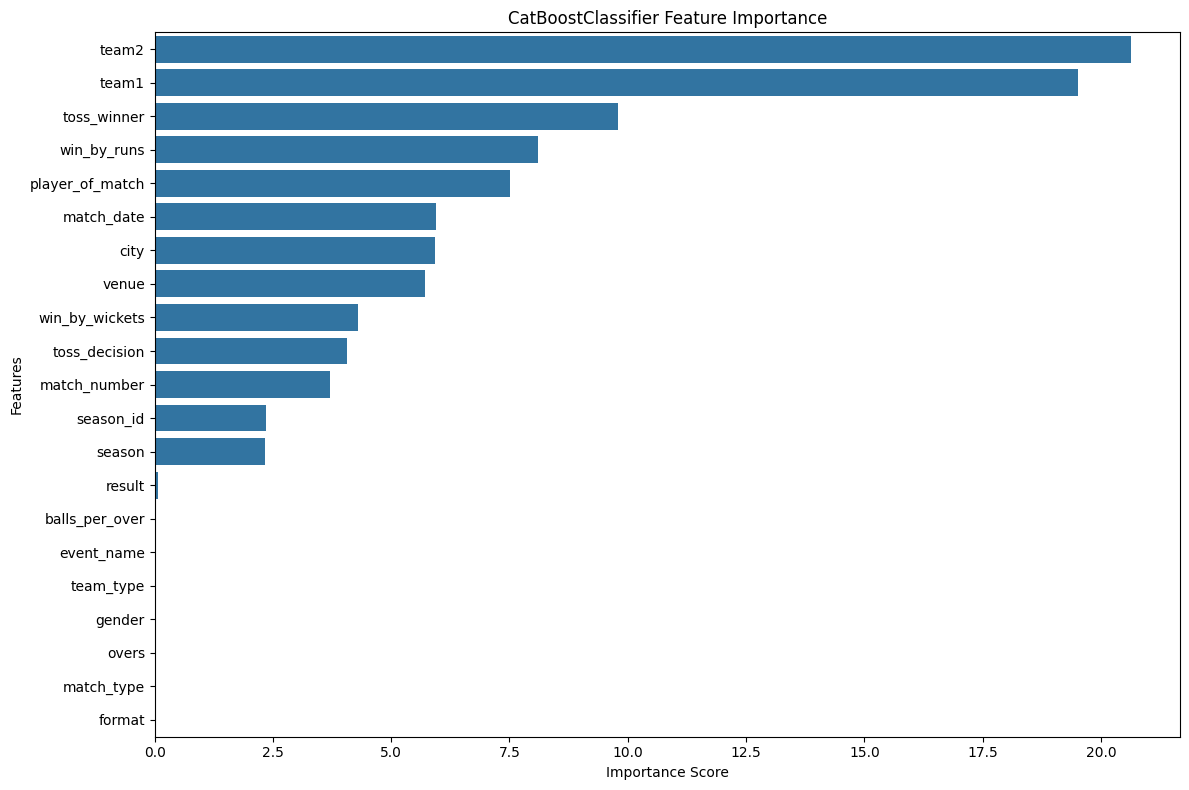

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best CatBoost model
feature_importances = model.get_feature_importance()

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': feature_importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('CatBoostClassifier Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Confusion Matrix

A confusion matrix helps visualize the performance of the classification model by showing the number of true positive, true negative, false positive, and false negative predictions.

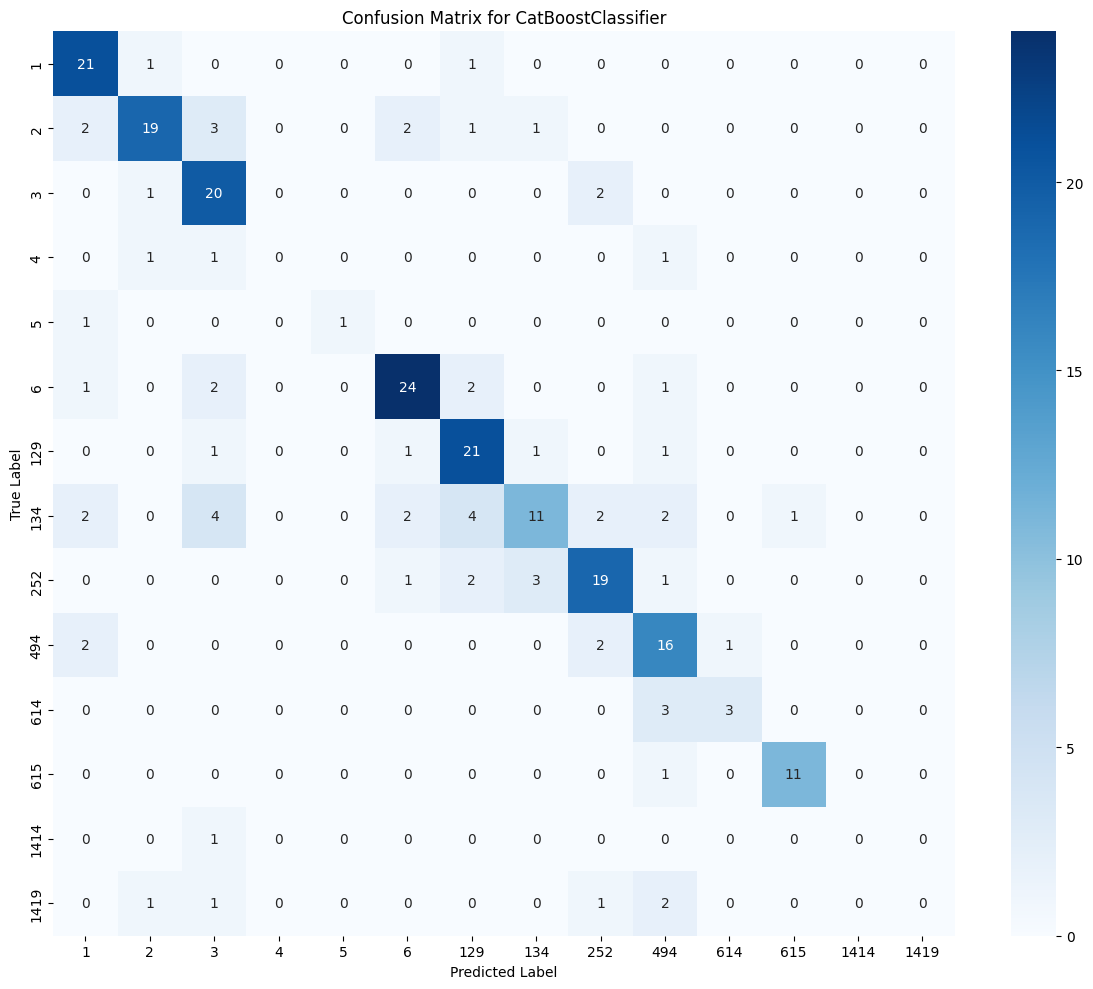

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on the test set using the trained model
y_pred = model.predict(x_test_scaled)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix for CatBoostClassifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()